## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use('default')

## Load

In [1]:
gateways_file = ('data/raw/Speed_Test_Interview_Project_Gateways_Table.csv')
speed_file = ('data/raw/Speed_Test_Interview_Project_Metrics_Table_v2.csv')
agg_file = ('data/processed/agg_df.csv')

gateways_df = pd.read_csv(gateways_file)
speed_df = pd.read_csv(speed_file)
agg_df = pd.read_csv(agg_file)

speed_df['Slow'] = speed_df['router_speedtest_tcp_64_download_Mbps_avg'] < 50
OUTPUT_COLUMN = 'Slow'
TARGET_COLUMN = 'router_speedtest_tcp_64_download_Mbps_avg' # column name or None
TIME_COLUMN = 'slot_timestamp'   # column name for time axis, or None

print(f'Shape: {gateways_df.shape}')
print(f'Shape: {speed_df.shape}')

NameError: name 'pd' is not defined

## Browse raw data

In [ ]:
# Fix datatypes to handle numeric IDs
numToStr1 = ['gateway_id','satellite_id','gateway_site_id']
for colName in numToStr1:
    gateways_df[colName] = gateways_df[colName].astype(str)

numToStr2 = ['cell_id','home_pop_id','gateway_id','satellite_id', 'ku_beam_target_cell_id']
for colName in numToStr2:
    speed_df[colName] = speed_df[colName].astype(str)

speed_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
router_speedtest_tcp_64_download_Mbps_avg,68119.0,NaN,NaN,NaN,162.608587,72.181862,0.336111,107.940971,161.543472,216.310555,395.930847
slot_timestamp,68119,26663,2021-12-18T03:47:42Z,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ut_ping_loss_rate,67955.0,NaN,NaN,NaN,0.041348,0.041387,0.0,0.013633,0.032218,0.056631,1.0
cell_id,68119,6115,1147498,905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_pop_id,68119,31,101,14406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gateway_id,68119,532,10553,695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
satellite_id,68119,1458,2209,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ut_snr,68119.0,NaN,NaN,NaN,9.062621,1.622487,-3.254718,8.270332,9.290804,10.144612,13.379181
expected_min_snr,68119.0,NaN,NaN,NaN,6.075836,0.492453,3.744998,5.695076,6.130506,6.495846,6.918958
ut_latency,68119.0,NaN,NaN,NaN,69.127558,50.497774,0.0,44.862519,62.826652,85.44461,7756.133875


In [ ]:
gateways_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
slot_timestamp,70319,25815,2021-12-18T03:47:42Z,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gateway_id,70319,533,10553,708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
satellite_id,70319,1458,2209,167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gateway_site_id,70319,73,20,4324,NaN,NaN,NaN,NaN,NaN,NaN,NaN
online_user_count,70319.0,NaN,NaN,NaN,1321.356973,818.201474,1.0,733.0,1185.0,1761.0,5078.0
ka_beam_avg_util_percent,70298.0,NaN,NaN,NaN,39.793223,23.790777,0.0,21.0,35.0,56.0,100.0
ka_beam_max_util_percent,70298.0,NaN,NaN,NaN,54.389741,23.942396,0.0,35.0,51.0,73.0,100.0
ka_beam_active_count,70292.0,NaN,NaN,NaN,6.464036,1.971861,2.0,4.0,8.0,8.0,8.0


In [ ]:
# Clean the link failure column
speed_df['link_failure_detected'] = speed_df['link_failure_detected'].fillna('Unknown')

# Encode gateway_site_id into speed_df
gateway_site_keys = gateways_df[['gateway_id', 'gateway_site_id']].drop_duplicates()
speed_df = speed_df.merge(gateway_site_keys, on='gateway_id', how='left')

# Encode pct of beam resource used by the user
speed_df['beam_pct_allocation'] = 1 / (speed_df['number_of_ku_beam_targets'] * speed_df['number_of_users_on_ku_beam_target'])
speed_df['beam_pct_allocation'] = speed_df['beam_pct_allocation'].replace([np.inf, -np.inf], np.nan)

# Remove features
speed_df = speed_df.drop(columns=['test_id'])

In [ ]:
# Nulls
def filter_or_flag_nulls(df, df_name, threshold_pct=1.0):
    print(f'\n{df_name} Missing Values:')
    high_null_cols = []

    for col in df.columns:
        n_null = df[col].isnull().sum()
        if n_null > 0:
            pct = 100 * n_null / len(df)
            if pct >= threshold_pct:
                print(f'  {col:30s} {n_null:6d} ({pct:5.1f}%)')
                high_null_cols.append(col)
            else:
                print(f'  {col:30s} {n_null:6d} ({pct:5.1f}%)')

    dropna_cols = [col for col in df.columns if col not in high_null_cols]
    df_clean = df.dropna(subset=dropna_cols)

    print(f'  Rows before: {len(df):,}\nafter: {len(df_clean):,}')
    return df_clean

speed_df    = filter_or_flag_nulls(speed_df,    'Speed_df')
gateways_df = filter_or_flag_nulls(gateways_df, 'Gateways_df')


Speed_df Missing Values:
  ut_ping_loss_rate                 164 (  0.2%)
  gateway_site_id                     2 (  0.0%)
  Rows before: 68,119
after: 67,953

Gateways_df Missing Values:
  ka_beam_avg_util_percent           21 (  0.0%)
  ka_beam_max_util_percent           21 (  0.0%)
  ka_beam_active_count               27 (  0.0%)
  Rows before: 70,319
after: 70,282


In [ ]:
# Categorize and count feature types
numeric_cols = []
categorical_cols = []

for col in speed_df.columns:
    if col in [TARGET_COLUMN, TIME_COLUMN, OUTPUT_COLUMN]:
        continue
    
    if speed_df[col].dtype in ['int64', 'float64']:
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)
print(f'Categorical features: {len(categorical_cols)}')
print(f'Numeric features: {len(numeric_cols)}')

numeric_cols_2 = []
categorical_cols_2 = []

for col in gateways_df.columns:
    if col in [TARGET_COLUMN, TIME_COLUMN, OUTPUT_COLUMN]:
        continue
    
    if gateways_df[col].dtype in ['int64', 'float64']:
        numeric_cols_2.append(col)
    else:
        categorical_cols_2.append(col)
print(f'Categorical features: {len(categorical_cols_2)}')
print(f'Numeric features: {len(numeric_cols_2)}')

Categorical features: 8
Numeric features: 10
Categorical features: 3
Numeric features: 4


In [ ]:
# Correlations with target
if TARGET_COLUMN and TARGET_COLUMN in speed_df.columns and speed_df[TARGET_COLUMN].dtype in ['int64', 'float64'] and numeric_cols:
    print(f'\nTop correlations with {TARGET_COLUMN}:')
    corrs = []
    for col in numeric_cols:
        c = speed_df[col].corr(speed_df[TARGET_COLUMN])
        corrs.append((col, c))
    
    corrs.sort(key=lambda x: abs(x[1]), reverse=True)
    for col, c in corrs[:10]:
        print(f'  {col:30s} {c:7.4f}')


Top correlations with router_speedtest_tcp_64_download_Mbps_avg:
  number_of_users_on_ku_beam     -0.4720
  ut_snr                          0.4433
  number_of_users_on_ku_beam_target -0.2711
  beam_pct_allocation             0.2569
  ut_ping_loss_rate              -0.2428
  ut_latency                     -0.2413
  number_of_ku_beam_targets      -0.1626
  local_hour                      0.0631
  expected_min_snr                0.0320
  ut_sat_elevation_angle_mean     0.0243


## Visualizations

In [ ]:
df_plot = speed_df.sample(n=min(10000, len(speed_df)), random_state=1).dropna() #subsample fewer data

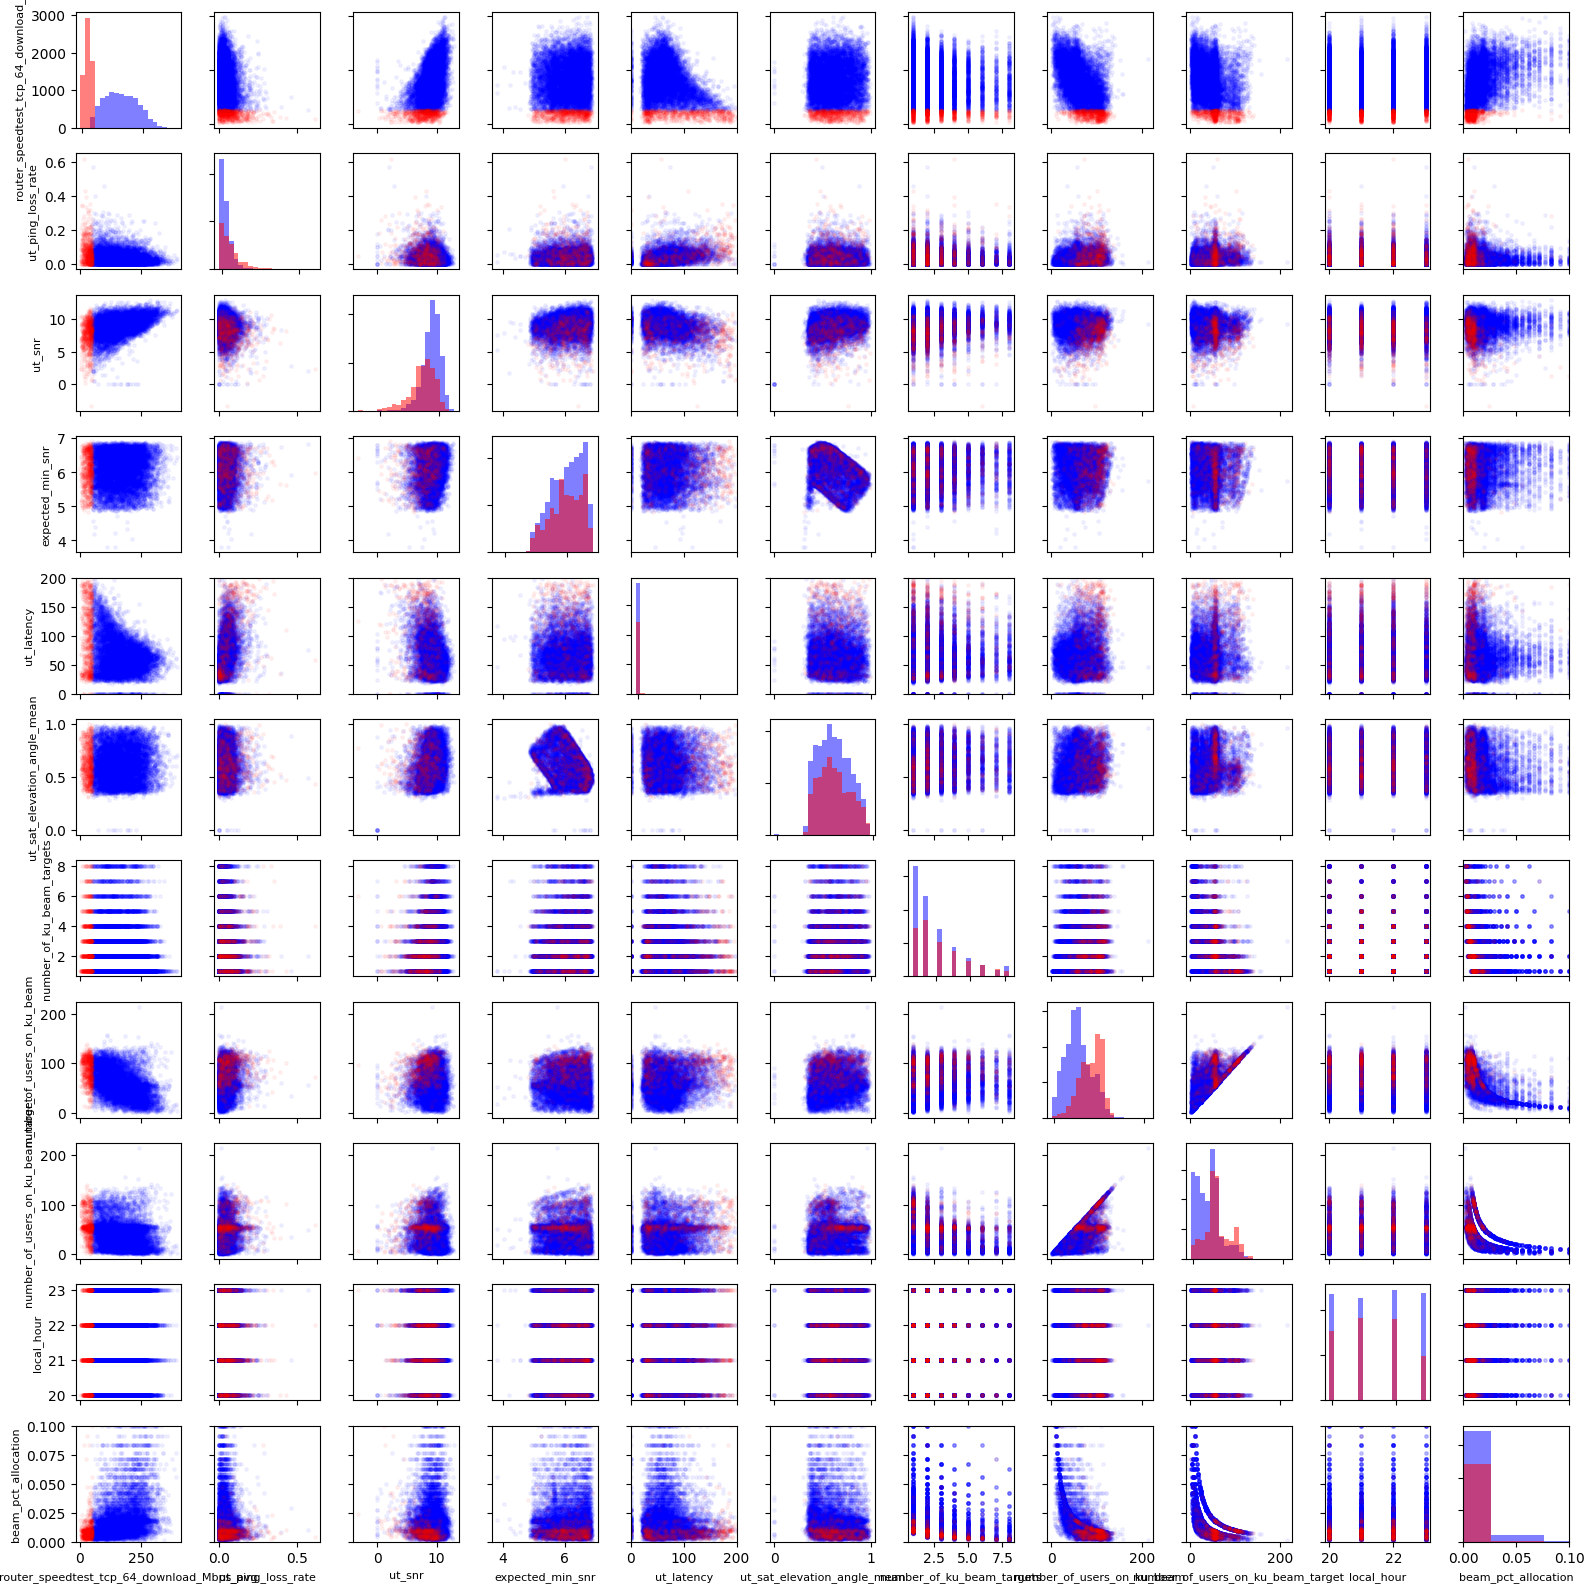

In [ ]:
# Plots of numeric columns
plot_type = 'grid_colored' # histogram or grid or grid_colored
plot_cols = numeric_cols[:11]

# Add target if numeric
if TARGET_COLUMN in df_plot.columns and df_plot[TARGET_COLUMN].dtype in ['int64', 'float64']:
    plot_cols = [TARGET_COLUMN] + plot_cols

if plot_cols:
    if plot_type == 'histogram':
        n_plots = len(plot_cols)
        fig, axes = plt.subplots(4, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for idx, col in enumerate(plot_cols):
            axes[idx].hist(df_plot[col], bins=40, edgecolor='black')
            axes[idx].set_title(col)
        
        # Hide unused
        for idx in range(n_plots, len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        
    elif plot_type == 'grid':
        n_cols = len(plot_cols)
        fig, axes = plt.subplots(n_cols, n_cols, figsize=(16, 16))
        
        for i in range(n_cols):
            for j in range(n_cols):
                ax = axes[i, j]
                
                if i == j:
                    # Diagonal: histogram
                    ax.hist(df_plot[plot_cols[i]], bins=20)
                else:
                    # Off-diagonal: scatter
                    ax.scatter(df_plot[plot_cols[j]], df_plot[plot_cols[i]], s=3, alpha=0.3)
                
                # Labels on edges only
                if j == 0:
                    ax.set_ylabel(plot_cols[i], fontsize=8)
                else:
                    ax.set_yticklabels([])
                
                if i == n_cols - 1:
                    ax.set_xlabel(plot_cols[j], fontsize=8)
                else:
                    ax.set_xticklabels([])
            plt.tight_layout()

    elif plot_type == 'grid_colored':
            n_cols = len(plot_cols)
            fig, axes = plt.subplots(n_cols, n_cols, figsize=(16, 16))
            
            for i in range(n_cols):
                for j in range(n_cols):
                    ax = axes[i, j]
                    
                    if i == j:
                        all_data = df_plot[plot_cols[i]]
                        counts_all, bins = np.histogram(all_data, bins=20)
                        # Diagonal: histogram with colors
                        for val, color in [(False, 'blue'), (True, 'red')]:
                            mask = df_plot[OUTPUT_COLUMN] == val
                            data = df_plot[mask][plot_cols[i]]
                            
                            counts, _ = np.histogram(data, bins=bins)  # Use shared bins
                            if val == True:
                                counts = counts * 10
                            
                            ax.bar(bins[:-1], counts, width=np.diff(bins), alpha=0.5, color=color, label=str(val))
                    else:
                        # Off-diagonal: scatter with colors
                        for val, color in [(False, 'blue'), (True, 'red')]:
                            mask = df_plot[OUTPUT_COLUMN] == val
                            ax.scatter(df_plot[mask][plot_cols[j]], 
                                    df_plot[mask][plot_cols[i]], 
                                    s=6, alpha=0.05, color=color, label=str(val))
                    

                    
                        if plot_cols[i] == 'ut_latency':
                            ax.set_ylim(0, 200)
                        if plot_cols[i] == 'beam_pct_allocation':
                            ax.set_ylim(0, 0.1)

                        if plot_cols[j] == 'ut_latency':
                            ax.set_xlim(0, 200)
                    if plot_cols[j] == 'beam_pct_allocation':
                        ax.set_xlim(0, 0.1)

                    if j == 0:
                        ax.set_ylabel(plot_cols[i], fontsize=8)
                    else:
                        ax.set_yticklabels([])
                    
                    if i == n_cols - 1:
                        ax.set_xlabel(plot_cols[j], fontsize=8)
                    else:
                        ax.set_xticklabels([])
            plt.tight_layout()

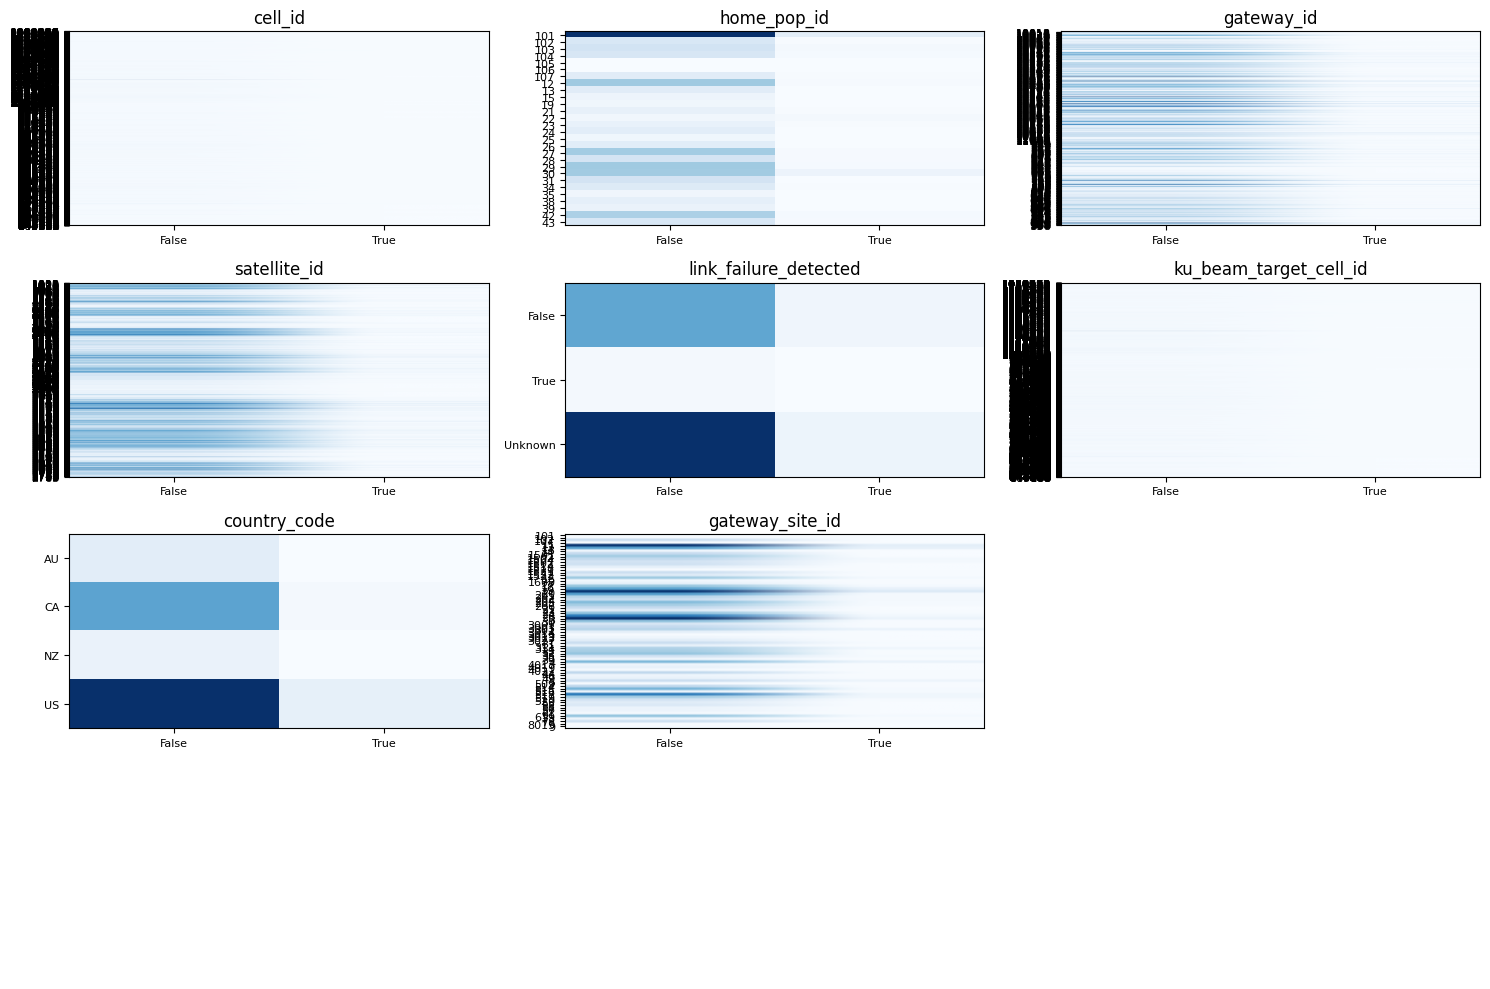

In [ ]:
# Barcharts categorical features
plot_type = 'multi'  # 'single' or 'multi'
plot_cols = categorical_cols[:11]

# Add target if categorical
if TARGET_COLUMN in df_plot.columns and df_plot[TARGET_COLUMN].dtype == 'object':
    plot_cols = [TARGET_COLUMN] + plot_cols


if plot_cols:
    if plot_type == 'single':
        n_plots = len(plot_cols)
        fig, axes = plt.subplots(4, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for idx, col in enumerate(plot_cols):
            df_plot[col].value_counts().head(15).plot(kind='bar', ax=axes[idx], edgecolor='black')
            axes[idx].set_title(col)
            axes[idx].set_xlabel('')
        
        # Hide unused
        for idx in range(n_plots, len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()

    # Categorical vs target heatmaps
    if plot_type == 'multi':
        n_plots = len(plot_cols)
        fig, axes = plt.subplots(4, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for idx, col in enumerate(plot_cols):
            # Crosstab: feature vs target
            ct = pd.crosstab(df_plot[col], df_plot[OUTPUT_COLUMN])
            
            
            im = axes[idx].imshow(ct.values, cmap='Blues', aspect='auto')
            axes[idx].set_xticks(range(len(ct.columns)))
            axes[idx].set_yticks(range(len(ct.index)))
            axes[idx].set_xticklabels(ct.columns, fontsize=8)
            axes[idx].set_yticklabels(ct.index, fontsize=8)
            axes[idx].set_title(col)
        
        # Hide unused
        for idx in range(n_plots, len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
    

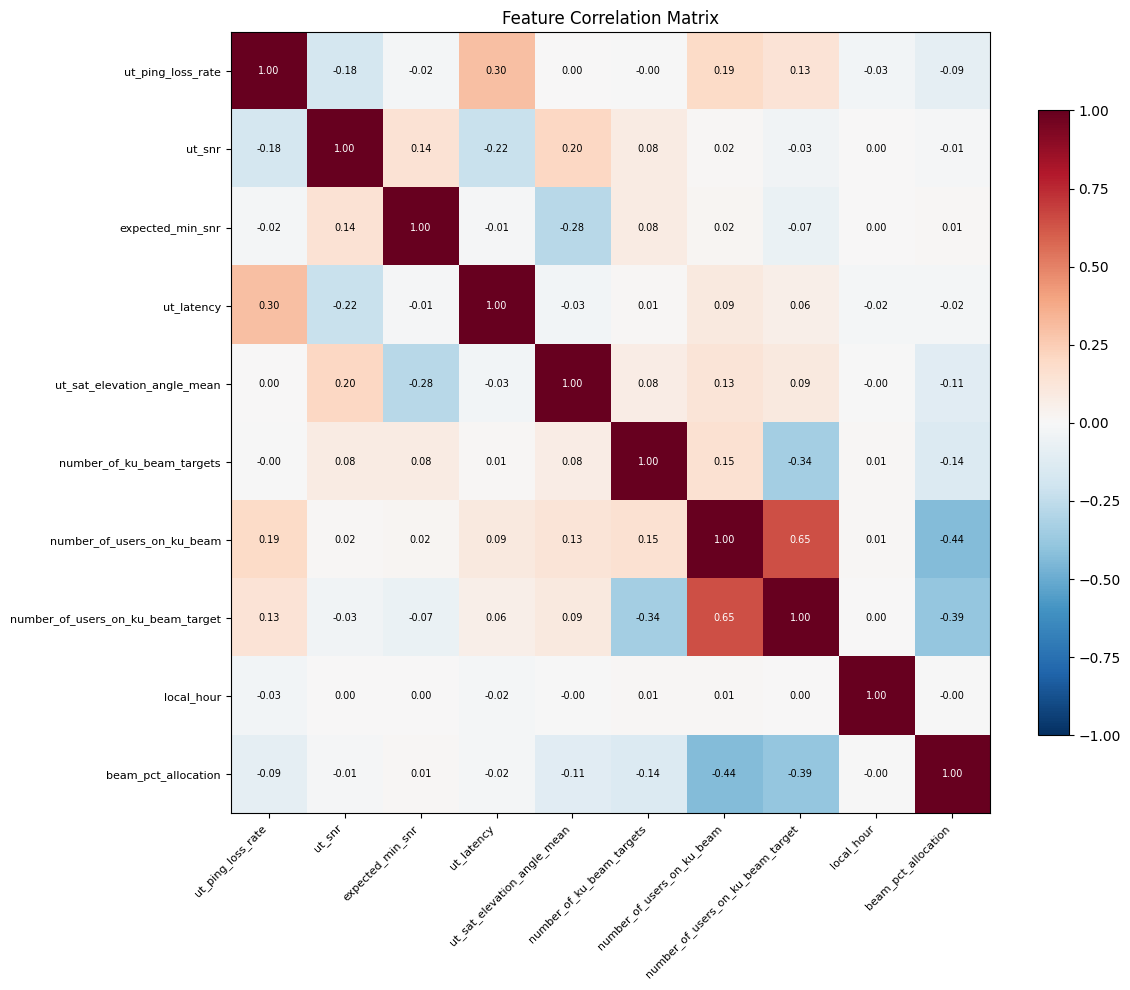

In [ ]:
# Correlation heatmap
if numeric_cols:
    corr_matrix = speed_df[numeric_cols].corr()
    n = len(numeric_cols)

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(numeric_cols, fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8)

    # Annotate
    if n <= 15:
        for i in range(n):
            for j in range(n):
                val = corr_matrix.values[i, j]
                color = 'white' if abs(val) > 0.6 else 'black'
                ax.text(j, i, f'{val:.2f}',
                        ha='center', va='center', fontsize=7, color=color)

    ax.set_title('Feature Correlation Matrix')
    plt.tight_layout()

## Browse aggregate data

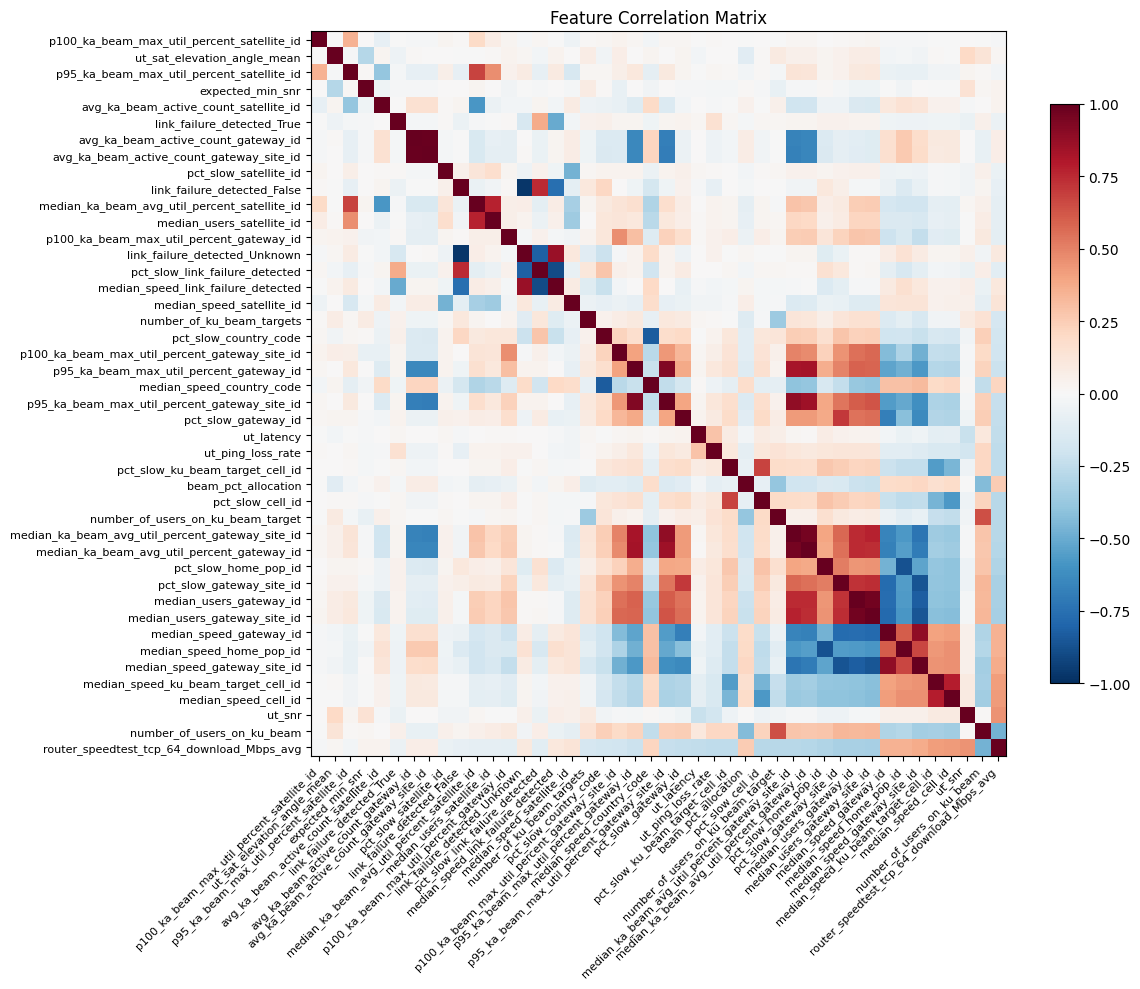

: 

In [ ]:
agg_num_df = agg_df.copy()
agg_num_df = pd.get_dummies(agg_num_df, columns=['link_failure_detected'], drop_first=False, dtype='int64')
agg_num_df = agg_num_df.drop(columns=[OUTPUT_COLUMN, TIME_COLUMN])

corr_matrix = agg_num_df.corr()
target_order = corr_matrix[TARGET_COLUMN].abs().sort_values().index
corr_matrix = corr_matrix.loc[target_order, target_order]
cols = corr_matrix.columns
n = len(cols)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(cols, fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)

# Annotate
if n <= 20:
    for i in range(n):
        for j in range(n):
            val = corr_matrix.values[i, j]
            color = 'white' if abs(val) > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}',
                    ha='center', va='center', fontsize=7, color=color)

ax.set_title('Feature Correlation Matrix')
plt.tight_layout()